In [13]:
# Cell 1 — installs
!pip install -q quantile-forest

# Cell 2 — Kaggle auth (upload your kaggle.json first: Kaggle account settings -> Create New API Token)
from google.colab import files
files.upload()  # select kaggle.json when prompted

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Cell 3 — download the main dataset
!kaggle datasets download -d ibrahimkiziloklu/solar-radiation-dataset -p data --unzip

# Cell 4 — sanity check
import pandas as pd
import glob
print(glob.glob("data/*.csv"))
df_preview = pd.read_csv(glob.glob("data/*.csv")[0])
df_preview.head()

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/ibrahimkiziloklu/solar-radiation-dataset
License(s): CC0-1.0
100% 6.08M/6.08M [00:01<00:00, 4.26MB/s]

['data/2017_2019.csv', 'data/2017.csv', 'data/2018.csv', 'data/2019.csv', 'data/solar_angles_dataset.csv']


,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Dew Point,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Surface Albedo,Pressure,Wind Speed,Unnamed: 18
0,2017,1,1,0,0,-0.6,0,0,0,-2.6,0,0,0,86.29,152.92,0.12,1003,1.7,NaN
1,2017,1,1,0,15,-0.6,0,0,0,-2.6,0,0,0,86.29,150.22,0.12,1003,1.7,NaN
2,2017,1,1,0,30,-0.6,0,0,0,-2.6,0,0,0,86.29,147.43,0.12,1003,1.7,NaN
3,2017,1,1,0,45,-0.6,0,0,0,-2.7,0,0,0,85.54,144.60,0.12,1003,1.6,NaN
4,2017,1,1,1,0,-0.7,0,0,0,-2.7,0,0,0,86.17,141.71,0.12,1003,1.6,NaN


In [14]:
# Cell 5 — preprocessing.py content (paste as one cell, or save to a .py file)

import pandas as pd
import numpy as np

def load_and_resample(path, freq="1h"):
    """Load raw 15-min NSRDB-style CSV, build a timestamp index, resample to hourly."""
    df = pd.read_csv(path)

    # drop junk column if present
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    # build timestamp from Year/Month/Day/Hour/Minute
    df["timestamp"] = pd.to_datetime(
        dict(year=df.Year, month=df.Month, day=df.Day,
             hour=df.Hour, minute=df.Minute)
    )
    df = df.set_index("timestamp").sort_index()

    # resample 15-min -> hourly (mean), drop the now-redundant calendar cols
    drop_cols = ["Year", "Month", "Day", "Hour", "Minute"]
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    df_hourly = df.resample(freq).mean()

    return df_hourly


def engineer_features(df):
    """Add calendar, lag, rolling, and clear-sky-index features. Target = GHI."""
    df = df.copy()

    # forward-fill missing values (sensor gaps) — never random-impute time series
    df = df.ffill().bfill()

    # calendar features
    df["hour"] = df.index.hour
    df["day_of_year"] = df.index.dayofyear
    df["month"] = df.index.month

    # clear-sky index: actual/clear-sky GHI, proxy for cloud cover (0=overcast,~1=clear)
    df["clearsky_index"] = np.where(
        df["Clearsky GHI"] > 1,
        df["GHI"] / df["Clearsky GHI"],
        0.0,
    )
    df["clearsky_index"] = df["clearsky_index"].clip(0, 1.5)

    # lag features on the target
    for lag in [1, 2, 3, 24]:
        df[f"GHI_lag_{lag}"] = df["GHI"].shift(lag)

    # rolling mean of last 3 hours (using only past values, shift(1) avoids leakage)
    df["GHI_roll_mean_3h"] = df["GHI"].shift(1).rolling(window=3).mean()

    # drop rows with NaNs created by lagging (start of series)
    df = df.dropna()

    return df


def train_test_split_ts(df, test_frac=0.2):
    """Chronological split — first 80% train, last 20% test. No shuffling."""
    n = len(df)
    split_idx = int(n * (1 - test_frac))
    train = df.iloc[:split_idx]
    test = df.iloc[split_idx:]
    return train, test


FEATURE_COLS = [
    "hour", "day_of_year", "month",
    "GHI_lag_1", "GHI_lag_2", "GHI_lag_3", "GHI_lag_24",
    "GHI_roll_mean_3h",
    "Temperature", "Wind Speed", "clearsky_index",
]
TARGET_COL = "GHI"


if __name__ == "__main__":
    raw = load_and_resample("data/2017_2019.csv")
    feat = engineer_features(raw)
    train, test = train_test_split_ts(feat)
    print(f"Total hourly rows after feature engineering: {len(feat)}")
    print(f"Train: {len(train)}  Test: {len(test)}")
    print(feat[FEATURE_COLS + [TARGET_COL]].head())

Total hourly rows after feature engineering: 26256
Train: 21004  Test: 5252
                     hour  day_of_year  month  GHI_lag_1  GHI_lag_2  \
timestamp                                                             
2017-01-02 00:00:00     0            2      1        0.0        0.0   
2017-01-02 01:00:00     1            2      1        0.0        0.0   
2017-01-02 02:00:00     2            2      1        0.0        0.0   
2017-01-02 03:00:00     3            2      1        0.0        0.0   
2017-01-02 04:00:00     4            2      1        0.0        0.0   

                     GHI_lag_3  GHI_lag_24  GHI_roll_mean_3h  Temperature  \
timestamp                                                                   
2017-01-02 00:00:00        0.0         0.0               0.0        0.450   
2017-01-02 01:00:00        0.0         0.0               0.0        0.250   
2017-01-02 02:00:00        0.0         0.0               0.0        0.050   
2017-01-02 03:00:00        0.0         0.

In [15]:
# Cell 6 — baseline Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def train_baseline_rf(train_df, feature_cols, target_col, n_estimators=300, random_state=42):
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    return model


def evaluate_baseline(model, test_df, feature_cols, target_col):
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    y_pred = model.predict(X_test)
    y_pred = np.clip(y_pred, 0, None)  # GHI can't be negative

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"Baseline RF — MAE: {mae:.2f} W/m²  RMSE: {rmse:.2f} W/m²  R²: {r2:.4f}")
    return {"mae": mae, "rmse": rmse, "r2": r2, "y_pred": y_pred, "y_test": y_test.values}


# --- run it ---
rf_model = train_baseline_rf(train, FEATURE_COLS, TARGET_COL)
baseline_results = evaluate_baseline(rf_model, test, FEATURE_COLS, TARGET_COL)

Baseline RF — MAE: 6.87 W/m²  RMSE: 17.41 W/m²  R²: 0.9968


In [16]:
# Cell 7 — Quantile Regression Forest

from quantile_forest import RandomForestQuantileRegressor
import numpy as np

QUANTILES = [0.10, 0.25, 0.50, 0.75, 0.90]

def train_qrf(train_df, feature_cols, target_col, n_estimators=300, random_state=42):
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    qrf = RandomForestQuantileRegressor(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=random_state,
    )
    qrf.fit(X_train, y_train)
    return qrf


def predict_quantiles(qrf, df, feature_cols, quantiles=QUANTILES):
    X = df[feature_cols]
    preds = qrf.predict(X, quantiles=quantiles)  # shape (n_samples, n_quantiles)
    preds = np.clip(preds, 0, None)  # GHI can't be negative
    # enforce monotonic non-crossing quantiles row-wise (can happen with forests)
    preds = np.sort(preds, axis=1)
    return preds  # columns ordered same as `quantiles`


def pinball_loss(y_true, y_pred, quantile):
    diff = y_true - y_pred
    return np.mean(np.maximum(quantile * diff, (quantile - 1) * diff))


def picp(y_true, lower, upper):
    """Prediction Interval Coverage Probability — fraction of true values inside [lower, upper]."""
    inside = (y_true >= lower) & (y_true <= upper)
    return np.mean(inside)


def pinaw(y_true, lower, upper):
    """Prediction Interval Normalized Average Width — width normalized by target range."""
    width = upper - lower
    y_range = y_true.max() - y_true.min()
    return np.mean(width) / y_range if y_range > 0 else np.nan


def evaluate_qrf(qrf, test_df, feature_cols, target_col, quantiles=QUANTILES):
    y_test = test_df[target_col].values
    preds = predict_quantiles(qrf, test_df, feature_cols, quantiles)

    q_idx = {q: i for i, q in enumerate(quantiles)}
    median_pred = preds[:, q_idx[0.50]]
    lower_80 = preds[:, q_idx[0.10]]
    upper_80 = preds[:, q_idx[0.90]]

    metrics = {}
    metrics["PICP_80"] = picp(y_test, lower_80, upper_80)  # target ~0.80
    metrics["PINAW_80"] = pinaw(y_test, lower_80, upper_80)

    metrics["pinball_loss"] = {
        q: pinball_loss(y_test, preds[:, q_idx[q]], q) for q in quantiles
    }

    print(f"QRF — PICP (10-90% band): {metrics['PICP_80']:.3f}  (target ≈ 0.80)")
    print(f"QRF — PINAW (10-90% band): {metrics['PINAW_80']:.4f}  (narrower = better)")
    for q, loss in metrics["pinball_loss"].items():
        print(f"  Pinball loss @ {int(q*100)}%: {loss:.3f}")

    return metrics, preds, y_test


# --- run it ---
qrf_model = train_qrf(train, FEATURE_COLS, TARGET_COL)
qrf_metrics, qrf_preds, y_test_arr = evaluate_qrf(qrf_model, test, FEATURE_COLS, TARGET_COL)

QRF — PICP (10-90% band): 0.957  (target ≈ 0.80)
QRF — PINAW (10-90% band): 0.0287  (narrower = better)
  Pinball loss @ 10%: 1.502
  Pinball loss @ 25%: 2.584
  Pinball loss @ 50%: 3.378
  Pinball loss @ 75%: 3.103
  Pinball loss @ 90%: 2.030


In [17]:
# Cell 7b — daytime-only coverage check
daytime_mask = test[TARGET_COL].values > 5  # GHI > 5 W/m^2 as a simple "sun is up" cutoff

y_test_day = y_test_arr[daytime_mask]
lower_80_day = qrf_preds[daytime_mask, 0]   # 10th percentile column
upper_80_day = qrf_preds[daytime_mask, 4]   # 90th percentile column

picp_day = picp(y_test_day, lower_80_day, upper_80_day)
pinaw_day = pinaw(y_test_day, lower_80_day, upper_80_day)

print(f"Daytime-only PICP (10-90% band): {picp_day:.3f}  (target ≈ 0.80)")
print(f"Daytime-only PINAW (10-90% band): {pinaw_day:.4f}")

Daytime-only PICP (10-90% band): 0.919  (target ≈ 0.80)
Daytime-only PINAW (10-90% band): 0.0553


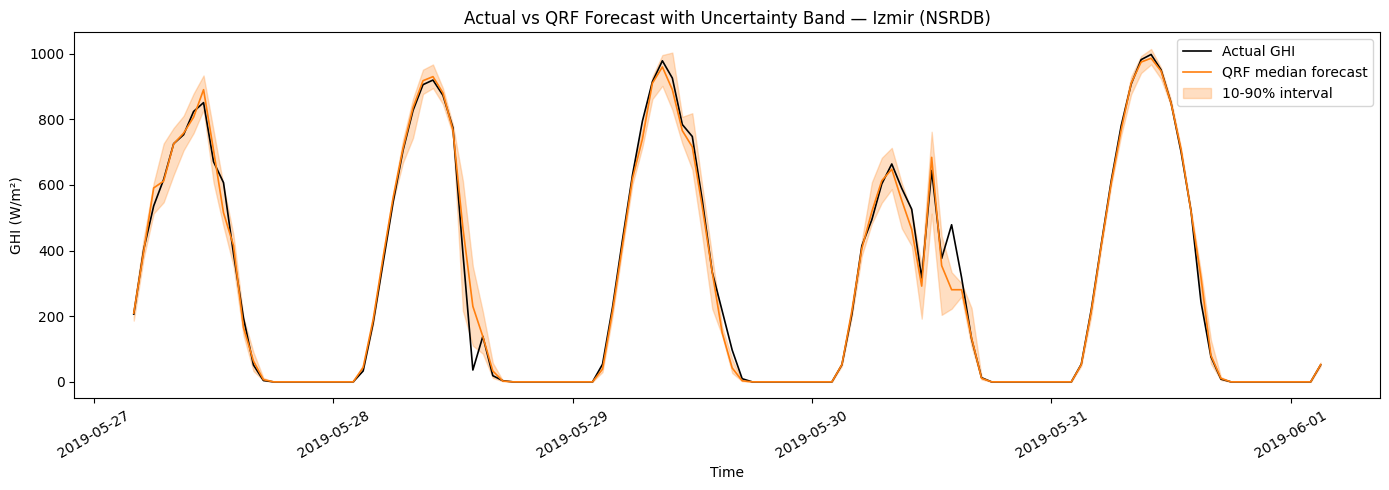

In [18]:
# Cell 8 — plot actual vs predicted with shaded 10-90% band
import matplotlib.pyplot as plt

def plot_forecast_band(test_df, y_test, preds, quantiles=QUANTILES, n_hours=24*5, title="Izmir-style site"):
    """Plot the first n_hours of the test set with actual vs median forecast + 10-90 band."""
    idx = test_df.index[:n_hours]
    y_true = y_test[:n_hours]
    q_idx = {q: i for i, q in enumerate(quantiles)}
    median = preds[:n_hours, q_idx[0.50]]
    lower = preds[:n_hours, q_idx[0.10]]
    upper = preds[:n_hours, q_idx[0.90]]

    plt.figure(figsize=(14, 5))
    plt.plot(idx, y_true, label="Actual GHI", color="black", linewidth=1.2)
    plt.plot(idx, median, label="QRF median forecast", color="tab:orange", linewidth=1.2)
    plt.fill_between(idx, lower, upper, color="tab:orange", alpha=0.25, label="10-90% interval")
    plt.xlabel("Time")
    plt.ylabel("GHI (W/m²)")
    plt.title(f"Actual vs QRF Forecast with Uncertainty Band — {title}")
    plt.legend()
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("results_izmir_forecast_band.png", dpi=150)
    plt.show()

plot_forecast_band(test, y_test_arr, qrf_preds, title="Izmir (NSRDB)")

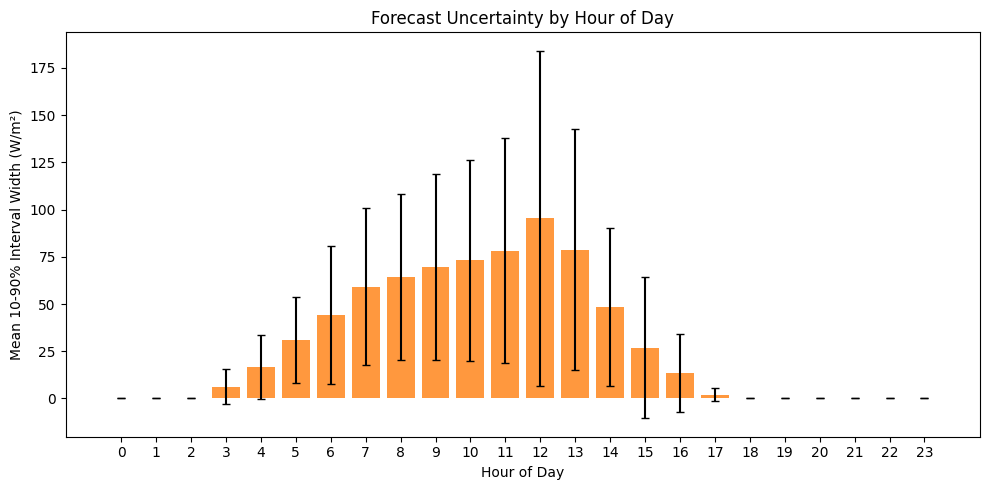

    hour       mean        std
0      0   0.000000   0.000000
1      1   0.000000   0.000000
2      2   0.000000   0.000000
3      3   6.220069   9.278959
4      4  16.712557  17.000837
5      5  30.801027  22.869390
6      6  44.198288  36.507773
7      7  59.244749  41.421169
8      8  64.206849  43.800771
9      9  69.543493  49.370269
10    10  73.189041  53.099796
11    11  78.217466  59.432269
12    12  95.392808  88.738367
13    13  78.749087  63.793842
14    14  48.396804  41.662715
15    15  26.892009  37.428680
16    16  13.565297  20.505483
17    17   1.950114   3.328237
18    18   0.000000   0.000000
19    19   0.000000   0.000000
20    20   0.000000   0.000000
21    21   0.000000   0.000000
22    22   0.000000   0.000000
23    23   0.000000   0.000000


In [19]:
# Cell 9 — interval width by hour of day
import numpy as np
import pandas as pd

def plot_uncertainty_by_hour(test_df, preds, quantiles=QUANTILES):
    q_idx = {q: i for i, q in enumerate(quantiles)}
    width_80 = preds[:, q_idx[0.90]] - preds[:, q_idx[0.10]]

    hour_df = pd.DataFrame({
        "hour": test_df["hour"].values,
        "width": width_80,
    })
    hourly_stats = hour_df.groupby("hour")["width"].agg(["mean", "std"]).reset_index()

    plt.figure(figsize=(10, 5))
    plt.bar(hourly_stats["hour"], hourly_stats["mean"],
            yerr=hourly_stats["std"], capsize=3, color="tab:orange", alpha=0.8)
    plt.xlabel("Hour of Day")
    plt.ylabel("Mean 10-90% Interval Width (W/m²)")
    plt.title("Forecast Uncertainty by Hour of Day")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.savefig("results_uncertainty_by_hour.png", dpi=150)
    plt.show()

    return hourly_stats

hourly_stats = plot_uncertainty_by_hour(test, qrf_preds)
print(hourly_stats)

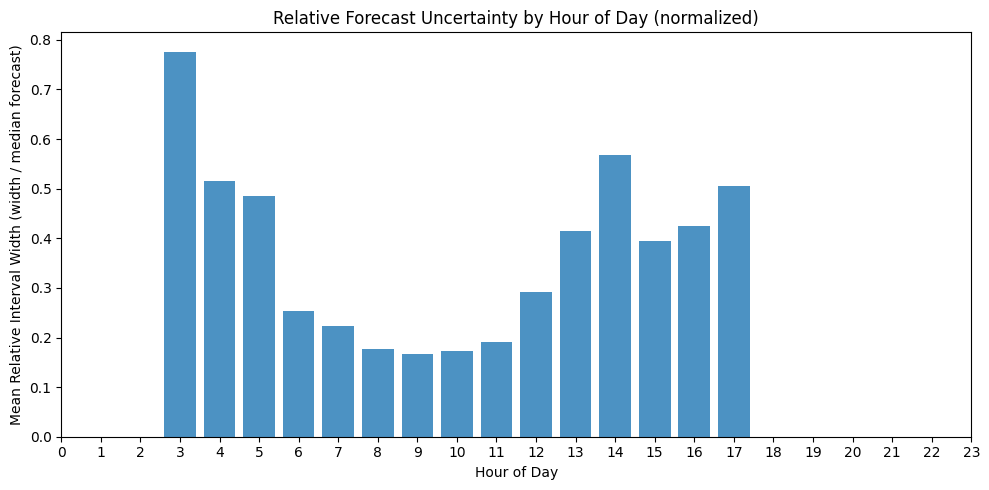

    hour  rel_width
0      3   0.776366
1      4   0.514593
2      5   0.486037
3      6   0.253920
4      7   0.222883
5      8   0.176211
6      9   0.165847
7     10   0.172574
8     11   0.191815
9     12   0.292667
10    13   0.414404
11    14   0.568822
12    15   0.394009
13    16   0.424725
14    17   0.506058


In [20]:
# Cell 9b — relative uncertainty by hour (normalized width)
def plot_relative_uncertainty_by_hour(test_df, preds, quantiles=QUANTILES):
    q_idx = {q: i for i, q in enumerate(quantiles)}
    width_80 = preds[:, q_idx[0.90]] - preds[:, q_idx[0.10]]
    median = preds[:, q_idx[0.50]]

    hour_df = pd.DataFrame({
        "hour": test_df["hour"].values,
        "width": width_80,
        "median": median,
    })
    # only daytime hours where median > 5 W/m^2, to avoid dividing by ~0
    hour_df = hour_df[hour_df["median"] > 5].copy()
    hour_df["rel_width"] = hour_df["width"] / hour_df["median"]

    hourly_rel = hour_df.groupby("hour")["rel_width"].mean().reset_index()

    plt.figure(figsize=(10, 5))
    plt.bar(hourly_rel["hour"], hourly_rel["rel_width"], color="tab:blue", alpha=0.8)
    plt.xlabel("Hour of Day")
    plt.ylabel("Mean Relative Interval Width (width / median forecast)")
    plt.title("Relative Forecast Uncertainty by Hour of Day (normalized)")
    plt.xticks(range(0, 24))
    plt.tight_layout()
    plt.savefig("results_relative_uncertainty_by_hour.png", dpi=150)
    plt.show()

    return hourly_rel

hourly_rel = plot_relative_uncertainty_by_hour(test, qrf_preds)
print(hourly_rel)

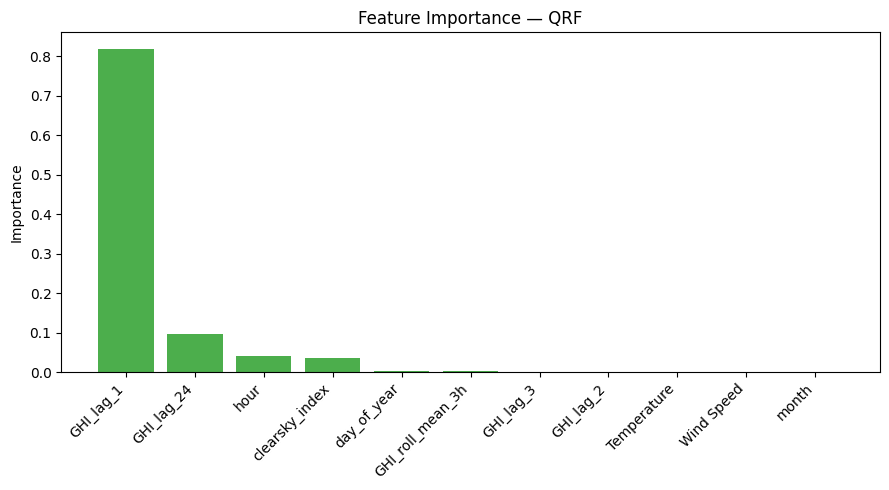

In [21]:
# Cell 10 — feature importance
def plot_feature_importance(model, feature_cols, title="QRF"):
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]

    plt.figure(figsize=(9, 5))
    plt.bar(range(len(feature_cols)), importances[order], color="tab:green", alpha=0.85)
    plt.xticks(range(len(feature_cols)), [feature_cols[i] for i in order], rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.title(f"Feature Importance — {title}")
    plt.tight_layout()
    plt.savefig(f"results_feature_importance_{title.lower()}.png", dpi=150)
    plt.show()

plot_feature_importance(qrf_model, FEATURE_COLS, title="QRF")

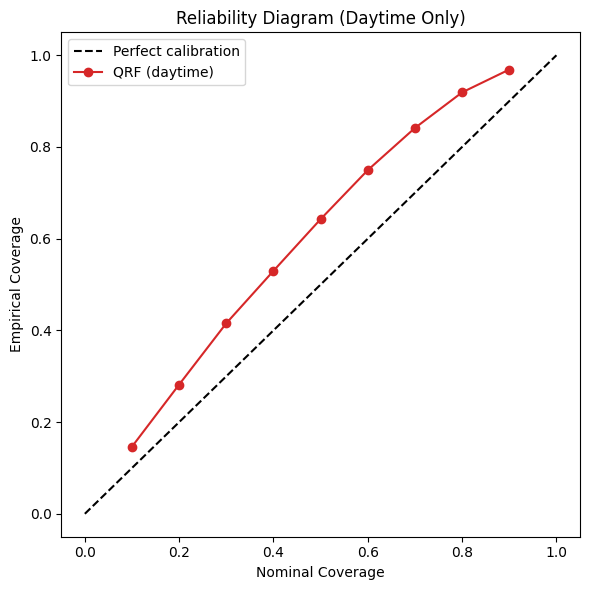

In [22]:
# Cell 11 — reliability diagram (calibration curve)
def plot_reliability_diagram(test_df, feature_cols, target_col, qrf, n_points=9):
    """For a range of nominal coverage levels, compute actual empirical coverage."""
    y_test = test_df[target_col].values
    daytime_mask = y_test > 5  # focus on daytime, same reasoning as before

    nominal_levels = np.linspace(0.1, 0.9, n_points)  # central intervals: 10%,20%,...,90%
    empirical_coverage = []

    for level in nominal_levels:
        lower_q = (1 - level) / 2
        upper_q = 1 - lower_q
        preds = predict_quantiles(qrf, test_df, feature_cols, quantiles=[lower_q, upper_q])
        lower = preds[:, 0][daytime_mask]
        upper = preds[:, 1][daytime_mask]
        cov = picp(y_test[daytime_mask], lower, upper)
        empirical_coverage.append(cov)

    plt.figure(figsize=(6, 6))
    plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    plt.plot(nominal_levels, empirical_coverage, "o-", color="tab:red", label="QRF (daytime)")
    plt.xlabel("Nominal Coverage")
    plt.ylabel("Empirical Coverage")
    plt.title("Reliability Diagram (Daytime Only)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("results_reliability_diagram.png", dpi=150)
    plt.show()

    return nominal_levels, empirical_coverage

nominal_levels, empirical_coverage = plot_reliability_diagram(test, FEATURE_COLS, TARGET_COL, qrf_model)

In [24]:
# Cell 12 (fixed) — download NSRDB data for Phoenix, AZ and Mumbai, India
import requests
import pandas as pd
import io

API_KEY = "MpYm6T8d4CcTJAdqC8es9cWPFVtjtj8a0y0ffLIv"   # paste your key here
EMAIL = "kasvi.r04@gmail.com"

def download_nsrdb(lat, lon, year, dataset, interval, out_path, api_key=API_KEY, email=EMAIL):
    """
    dataset options:
      'nsrdb-GOES-aggregated-v4-0-0' -> Americas (Phoenix). interval: 30 or 60.
      'msg-iodc'                     -> India/Middle East/Africa (Mumbai). interval: 15, 30, or 60.
    """
    url = (
        f"https://developer.nlr.gov/api/nsrdb/v2/solar/{dataset}-download.csv"
        f"?wkt=POINT({lon}%20{lat})"
        f"&names={year}"
        f"&leap_day=false"
        f"&interval={interval}"
        f"&utc=false"
        f"&full_name=Colab+User"
        f"&email={email}"
        f"&affiliation=Independent"
        f"&reason=Research"
        f"&api_key={api_key}"
        f"&attributes=ghi,clearsky_ghi,air_temperature,wind_speed"
    )
    r = requests.get(url)
    r.raise_for_status()
    df = pd.read_csv(io.StringIO(r.text), skiprows=2)  # skip 2 metadata header rows
    df.to_csv(out_path, index=False)
    print(f"Saved {out_path}  ({len(df)} rows)")
    return df

# Phoenix, AZ — desert (GOES covers the Americas, 60-min interval)
phoenix_2019 = download_nsrdb(33.4484, -112.0740, 2019, "nsrdb-GOES-aggregated-v4-0-0", 60, "data/phoenix_2019.csv")

# Mumbai, India — tropical/monsoon (Meteosat IODC covers India, only 2017-2019 available)
mumbai_2019 = download_nsrdb(19.0760, 72.8777, 2019, "msg-iodc", 60, "data/mumbai_2019.csv")

Saved data/phoenix_2019.csv  (8760 rows)
Saved data/mumbai_2019.csv  (8760 rows)


In [25]:
# Cell 12b — sanity check columns
print("Phoenix columns:", list(phoenix_2019.columns))
print(phoenix_2019.head())
print()
print("Mumbai columns:", list(mumbai_2019.columns))
print(mumbai_2019.head())

Phoenix columns: ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'Clearsky GHI', 'Temperature', 'Wind Speed']
   Year  Month  Day  Hour  Minute  GHI  Clearsky GHI  Temperature  Wind Speed
0  2019      1    1     0      30    0             0          2.2         0.8
1  2019      1    1     1      30    0             0          1.8         0.8
2  2019      1    1     2      30    0             0          1.7         0.8
3  2019      1    1     3      30    0             0          1.7         0.7
4  2019      1    1     4      30    0             0          2.0         0.5

Mumbai columns: ['Year', 'Month', 'Day', 'Hour', 'Minute', 'GHI', 'Clearsky GHI', 'Temperature', 'Wind Speed']
   Year  Month  Day  Hour  Minute  GHI  Clearsky GHI  Temperature  Wind Speed
0  2019      1    1     0      30    0             0         18.7         1.5
1  2019      1    1     1      30    0             0         18.4         1.5
2  2019      1    1     2      30    0             0         18.1         

In [27]:
# Cell 13 — full pipeline as one reusable function

def run_full_pipeline(csv_path, site_name):
    """Runs preprocessing -> baseline RF -> QRF -> metrics for one site. Returns a results dict."""
    print(f"\n{'='*60}\n{site_name}\n{'='*60}")

    # Step 1: preprocessing
    raw = load_and_resample(csv_path)
    feat = engineer_features(raw)
    train_site, test_site = train_test_split_ts(feat)
    print(f"Rows after feature engineering: {len(feat)}  (train={len(train_site)}, test={len(test_site)})")

    # Step 2: baseline RF
    rf = train_baseline_rf(train_site, FEATURE_COLS, TARGET_COL)
    baseline_res = evaluate_baseline(rf, test_site, FEATURE_COLS, TARGET_COL)

    # Step 3: QRF
    qrf = train_qrf(train_site, FEATURE_COLS, TARGET_COL)
    qrf_metrics_site, qrf_preds_site, y_test_site = evaluate_qrf(qrf, test_site, FEATURE_COLS, TARGET_COL)

    # daytime-only PICP/PINAW (as we established, this is the fair comparison)
    daytime_mask = y_test_site > 5
    lower_80 = qrf_preds_site[daytime_mask, 0]
    upper_80 = qrf_preds_site[daytime_mask, 4]
    picp_day = picp(y_test_site[daytime_mask], lower_80, upper_80)
    pinaw_day = pinaw(y_test_site[daytime_mask], lower_80, upper_80)
    print(f"Daytime PICP: {picp_day:.3f}   Daytime PINAW: {pinaw_day:.4f}")

    return {
        "site_name": site_name,
        "train_df": train_site,
        "test_df": test_site,
        "rf_model": rf,
        "qrf_model": qrf,
        "baseline_metrics": baseline_res,
        "qrf_metrics": qrf_metrics_site,
        "qrf_preds": qrf_preds_site,
        "y_test": y_test_site,
        "picp_daytime": picp_day,
        "pinaw_daytime": pinaw_day,
    }


# --- run all 3 sites ---
results_izmir = run_full_pipeline("data/2017_2019.csv", "Izmir, Turkey (Mediterranean)")
results_phoenix = run_full_pipeline("data/phoenix_2019.csv", "Phoenix, Arizona (Desert)")
results_mumbai = run_full_pipeline("data/mumbai_2019.csv", "Mumbai, India (Tropical/Monsoon)")


Izmir, Turkey (Mediterranean)
Rows after feature engineering: 26256  (train=21004, test=5252)
Baseline RF — MAE: 6.87 W/m²  RMSE: 17.41 W/m²  R²: 0.9968
QRF — PICP (10-90% band): 0.957  (target ≈ 0.80)
QRF — PINAW (10-90% band): 0.0287  (narrower = better)
  Pinball loss @ 10%: 1.502
  Pinball loss @ 25%: 2.584
  Pinball loss @ 50%: 3.378
  Pinball loss @ 75%: 3.103
  Pinball loss @ 90%: 2.030
Daytime PICP: 0.919   Daytime PINAW: 0.0553

Phoenix, Arizona (Desert)
Rows after feature engineering: 8736  (train=6988, test=1748)
Baseline RF — MAE: 19.49 W/m²  RMSE: 41.90 W/m²  R²: 0.9638
QRF — PICP (10-90% band): 0.927  (target ≈ 0.80)
QRF — PINAW (10-90% band): 0.0809  (narrower = better)
  Pinball loss @ 10%: 2.542
  Pinball loss @ 25%: 5.504
  Pinball loss @ 50%: 8.637
  Pinball loss @ 75%: 8.244
  Pinball loss @ 90%: 5.407
Daytime PICP: 0.831   Daytime PINAW: 0.1935

Mumbai, India (Tropical/Monsoon)
Rows after feature engineering: 8736  (train=6988, test=1748)
Baseline RF — MAE: 27.39 

In [28]:
# Cell 14 — build the final comparison table

all_results = [results_izmir, results_phoenix, results_mumbai]

comparison_rows = []
for res in all_results:
    comparison_rows.append({
        "Site": res["site_name"],
        "RF_MAE": res["baseline_metrics"]["mae"],
        "RF_RMSE": res["baseline_metrics"]["rmse"],
        "RF_R2": res["baseline_metrics"]["r2"],
        "QRF_PICP_daytime": res["picp_daytime"],
        "QRF_PINAW_daytime": res["pinaw_daytime"],
        "Pinball_10": res["qrf_metrics"]["pinball_loss"][0.10],
        "Pinball_50": res["qrf_metrics"]["pinball_loss"][0.50],
        "Pinball_90": res["qrf_metrics"]["pinball_loss"][0.90],
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Site")
comparison_df = comparison_df.round(4)
comparison_df.to_csv("results_comparison_table.csv")
comparison_df

,RF_MAE,RF_RMSE,RF_R2,QRF_PICP_daytime,QRF_PINAW_daytime,Pinball_10,Pinball_50,Pinball_90
Site,,,,,,,,
"Izmir, Turkey (Mediterranean)",6.8664,17.4121,0.9968,0.9191,0.0553,1.5025,3.3781,2.0300
"Phoenix, Arizona (Desert)",19.4862,41.8975,0.9638,0.8313,0.1935,2.5420,8.6367,5.4074
"Mumbai, India (Tropical/Monsoon)",27.3926,50.2318,0.9604,0.7232,0.1909,4.5113,13.5092,6.1854


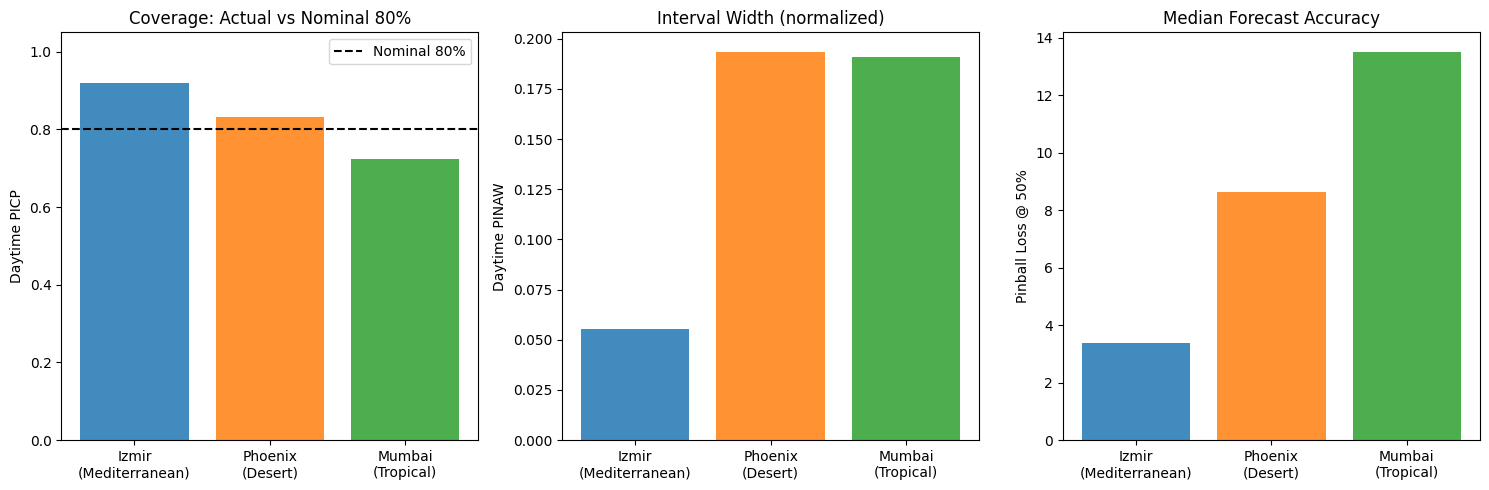

In [29]:
# Cell 15 — 3-panel comparison across sites

import numpy as np

sites = [r["site_name"] for r in all_results]
picp_vals = [r["picp_daytime"] for r in all_results]
pinaw_vals = [r["pinaw_daytime"] for r in all_results]
pinball_50_vals = [r["qrf_metrics"]["pinball_loss"][0.50] for r in all_results]

short_names = ["Izmir\n(Mediterranean)", "Phoenix\n(Desert)", "Mumbai\n(Tropical)"]
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: PICP vs nominal 80%
axes[0].bar(short_names, picp_vals, color=colors, alpha=0.85)
axes[0].axhline(0.80, color="black", linestyle="--", label="Nominal 80%")
axes[0].set_ylabel("Daytime PICP")
axes[0].set_title("Coverage: Actual vs Nominal 80%")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Panel 2: PINAW (interval sharpness)
axes[1].bar(short_names, pinaw_vals, color=colors, alpha=0.85)
axes[1].set_ylabel("Daytime PINAW")
axes[1].set_title("Interval Width (normalized)")

# Panel 3: Pinball loss at median
axes[2].bar(short_names, pinball_50_vals, color=colors, alpha=0.85)
axes[2].set_ylabel("Pinball Loss @ 50%")
axes[2].set_title("Median Forecast Accuracy")

plt.tight_layout()
plt.savefig("results_cross_site_comparison.png", dpi=150)
plt.show()